<a href="https://colab.research.google.com/github/asmi04513/klasifikasi_dataminingteori/blob/main/klasifikasi_uasteori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None


Missing values per kolom:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Statistik deskriptif (numerik):


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Distribusi kelas target (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64


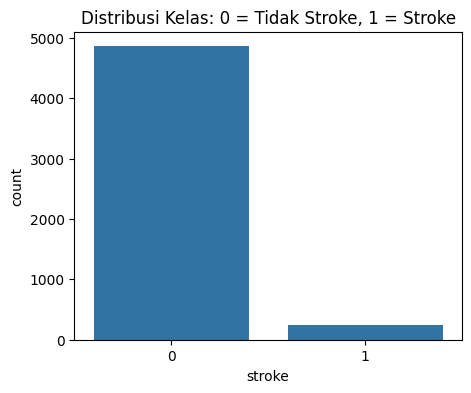

In [3]:
#EDA Menganalisis distribusi data dan kualitas fitur
print("Info dataset:")
display(df.info())

print("\nMissing values per kolom:")
print(df.isnull().sum())

print("\nStatistik deskriptif (numerik):")
display(df.describe())

print("\nDistribusi kelas target (stroke):")
print(df['stroke'].value_counts())

# Visualisasi distribusi target
plt.figure(figsize=(5,4))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Kelas: 0 = Tidak Stroke, 1 = Stroke')
plt.show()

In [4]:
# Melakukan preprocessing
# Periksa missing di kolom bmi
print("Missing BMI sebelum:", df['bmi'].isnull().sum())

#melakukan imputasi(mencegah eror) Isi dengan median (lebih tahan outlier daripada mean)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print("Missing BMI setelah:", df['bmi'].isnull().sum())

Missing BMI sebelum: 201
Missing BMI setelah: 0


In [5]:
# ENCODING mengubah teks menjadi angka
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()

# Simpan mapping untuk tiap kolom agar bisa dilaporkan
mappings = {}

for col in categorical_cols:
    df[col] = df[col].astype(str)  # pastikan string
    df[col] = le.fit_transform(df[col])
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Hasil encoding (5 baris):")
display(df[categorical_cols].head())
print("\nMapping label untuk tiap kolom:")
for k, v in mappings.items():
    print(f"{k} -> {v}")

Hasil encoding (5 baris):


,gender,ever_married,work_type,Residence_type,smoking_status
0,1,1,2,1,1
1,0,1,3,0,2
2,1,1,2,0,2
3,0,1,2,1,3
4,0,1,3,0,2



Mapping label untuk tiap kolom:
gender -> {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
ever_married -> {'No': np.int64(0), 'Yes': np.int64(1)}
work_type -> {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type -> {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status -> {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


In [6]:
# Merapikan data pelatihan dan pengujian
#memisahkan X (fitur) dan y (target)
X = df.drop('stroke', axis=1)
y = df['stroke']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nDistribusi target (sebelum split):")
print(y.value_counts())

X shape: (5110, 11)
y shape: (5110,)

Distribusi target (sebelum split):
stroke
0    4861
1     249
Name: count, dtype: int64


In [7]:
# TRAIN-TEST SPLIT mendapatkan set training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran setelah split:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Distribusi y_train:")
print(y_train.value_counts())
print("Distribusi y_test:")
print(y_test.value_counts())
#supaya distribusi 1 dan 0 di train/test tetap sama. mencegah skenario
# test set dengan 0/1 yang sangat tidak representatif.

Ukuran setelah split:
X_train: (4088, 11) X_test: (1022, 11)
Distribusi y_train:
stroke
0    3889
1     199
Name: count, dtype: int64
Distribusi y_test:
stroke
0    972
1     50
Name: count, dtype: int64


In [12]:
# Menguji dan membandingkan beberapa algoritma klasifikasi
rf_default = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_default.fit(X_train, y_train)
pred_default = rf_default.predict(X_test)

print("random forest sebelum:")
print("Accuracy:", accuracy_score(y_test, pred_default))
print(classification_report(y_test, pred_default, zero_division=0))

random forest sebelum:
Accuracy: 0.9500978473581213
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [9]:
#Mengatasi ketidakseimbangan data
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

rf_ros = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_ros.fit(X_train_ros, y_train_ros)
pred_ros = rf_ros.predict(X_test)

print("Random Forest setelah oversampling Results:")
print("Accuracy:", accuracy_score(y_test, pred_ros))
print(classification_report(y_test, pred_ros, zero_division=0))

Random Forest setelah oversampling Results:
Accuracy: 0.9001956947162426
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       972
           1       0.23      0.44      0.30        50

    accuracy                           0.90      1022
   macro avg       0.60      0.68      0.62      1022
weighted avg       0.93      0.90      0.91      1022



In [11]:
# ========== 14) RINGKASAN METRIK PENTING ==========
def summarize(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision_macro": round(np.mean([precision_score(y_true, y_pred, pos_label=0, zero_division=0),
                                         precision_score(y_true, y_pred, pos_label=1, zero_division=0)]),4),
        "recall_macro": round(np.mean([recall_score(y_true, y_pred, pos_label=0, zero_division=0),
                                         recall_score(y_true, y_pred, pos_label=1, zero_division=0)]),4),
        "f1_macro": round(np.mean([f1_score(y_true, y_pred, pos_label=0, zero_division=0),
                                   f1_score(y_true, y_pred, pos_label=1, zero_division=0)]),4)
    }

rows = []
for name, preds in models_preds.items():
    rows.append(summarize(name, y_test, preds))

summary_df = pd.DataFrame(rows).set_index('model')
display(summary_df)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Random Forest (Default),0.9501,0.4755,0.4995,0.4872
Random Forest (Oversampled),0.9002,0.5995,0.6819,0.6238
